   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 2.8 MB/s eta 0:00:00
linearmodels found. Using IV2SLS for correct standard errors.
Mounted at /content/drive
Clean file found.

Dataset shape         : (1345350, 7)
Median annual income  : $65,000
Overall default rate  : 0.200
  Low Income          : 0.222
  High Income         : 0.176


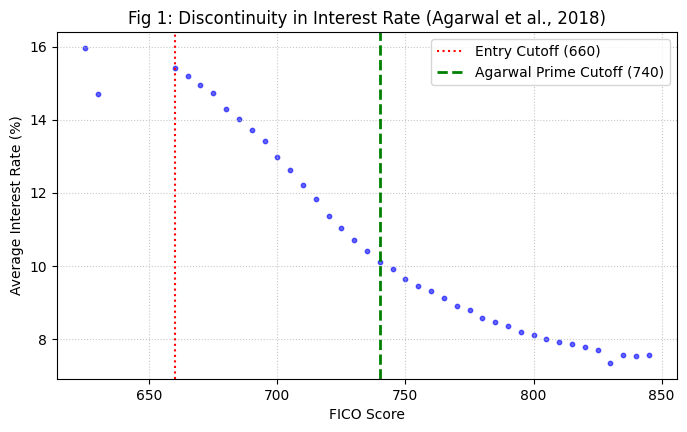


Subset size within bandwidth [715, 765]: N = 273,631


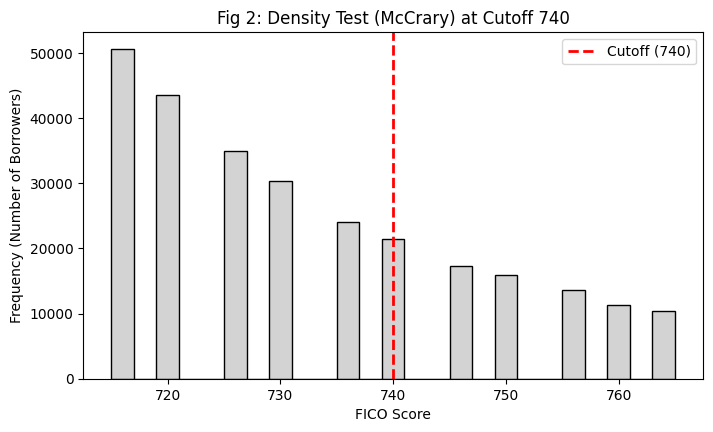


 STAGE 1: Effect of Threshold (740) on Interest Rate
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        10.2222      0.020    522.314      0.000      10.184      10.261
threshold         0.0586      0.032      1.819      0.069      -0.005       0.122
fico_centered    -0.0581      0.001    -56.343      0.000      -0.060      -0.056

  First-Stage F-statistic on instrument (threshold): 3.31
  H1a: NOT SUPPORTED — weak instrument (F <= 10). See §6.1.

 STAGE 2 (LATE via IV2SLS): Effect of Interest Rate on Default
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
---------------------------------------------------------------------------------
const            -0.0223     0.4543    -0.0491     0.9609     -0.9127      0.8681
fico_centered    -0.0005 

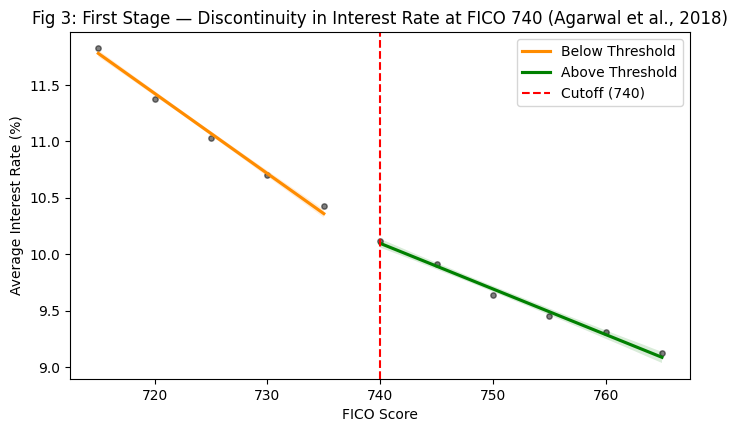

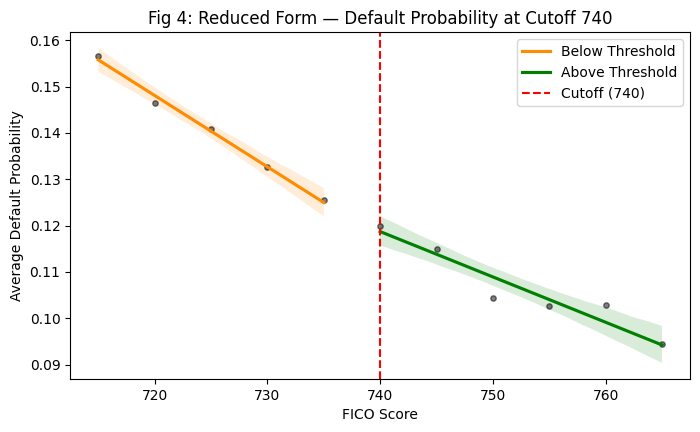

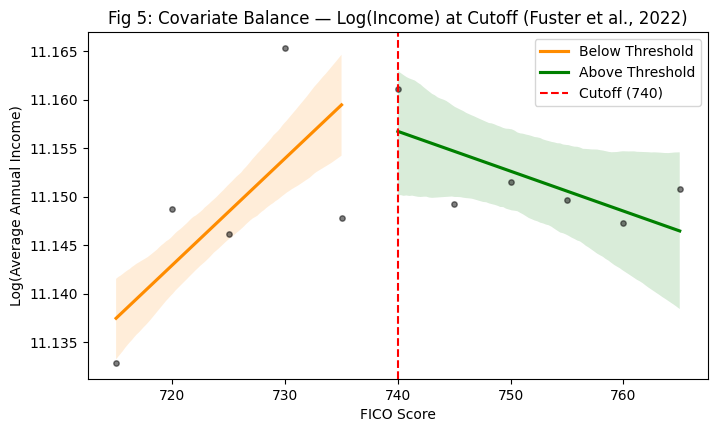


  Balance t-test on log(income): t = -2.458, p = 0.0140
  Significant income discontinuity detected — threat to validity (§6.1).

 Balance check complete — see §6.1 for discussion of income discontinuity.

 HETEROGENEITY ANALYSIS: Distributional Impacts (Fuster et al., 2022)
  Median Income Threshold: $65,000
  -> LATE (Rate → Default) for LOW Income:  0.0877  (p = 0.0937*)
  -> LATE (Rate → Default) for HIGH Income: -0.3570  (p = 0.7062)

  H1c: Low-income borrowers do not show larger sensitivity in this bandwidth.
  Non-significance in subgroups is expected given reduced N (§5.1).

 TABLE 1 — Descriptive Statistics at FICO 740 Cutoff (§4.1)
                 Below Threshold (FICO < 740)  Above Threshold (FICO ≥ 740)
int_rate   mean                         11.20                          9.68
           std                           4.21                          3.81
           min                           5.31                          5.31
           max                          30.9

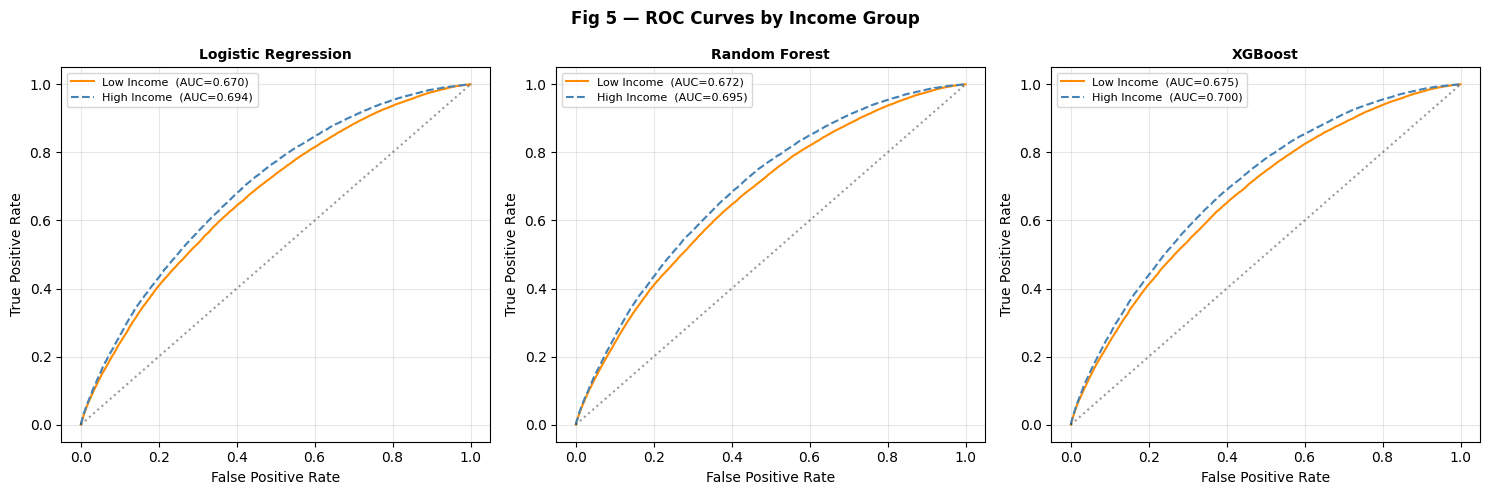

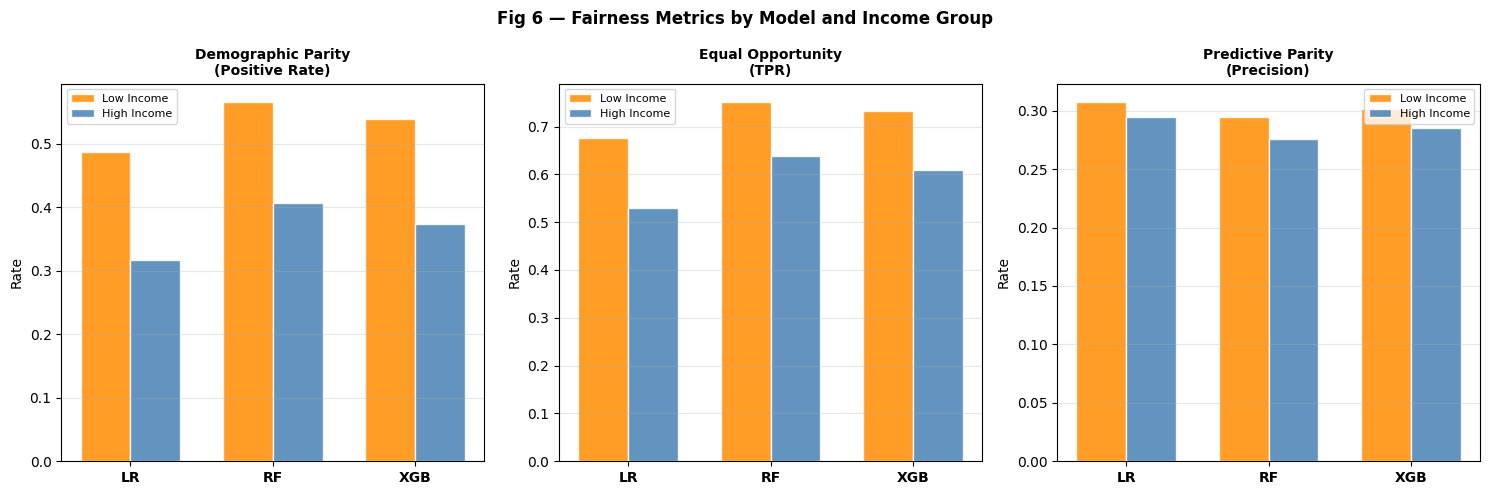


 SHAP ANALYSIS — XGBoost Feature Importance by Income Group


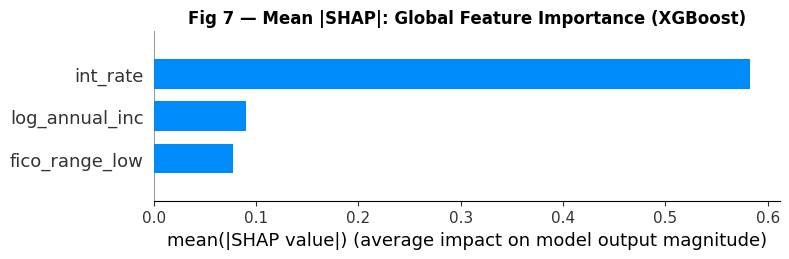

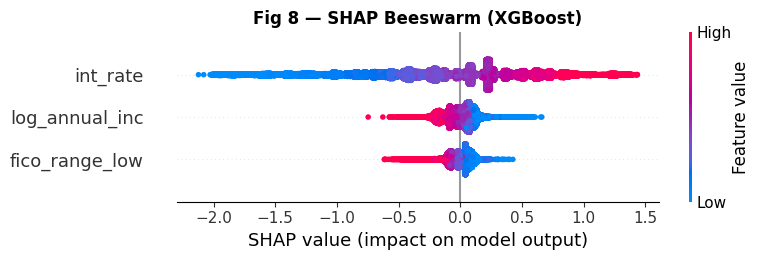


  Mean |SHAP| by income group (Table 4, §5.3):
       Feature  Low Income  High Income
fico_range_low    0.069230     0.085690
      int_rate    0.537437     0.631029
log_annual_inc    0.081788     0.100342


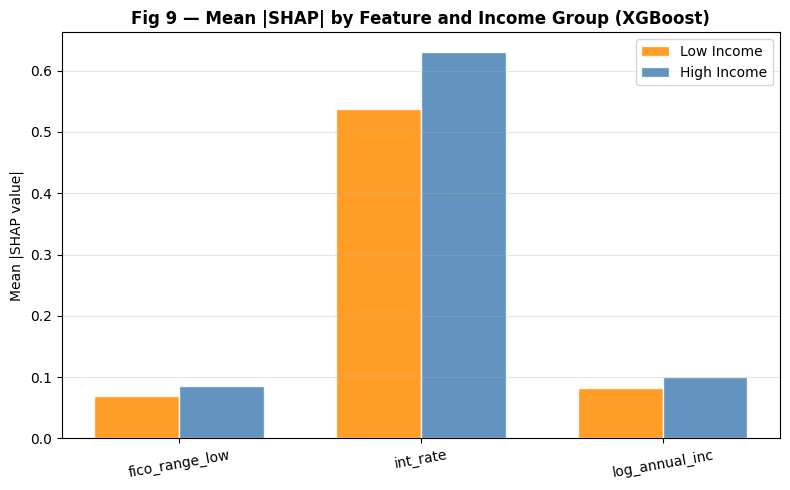


 CONDITIONAL FAIRNESS — Within-FICO Quintile Analysis (§5.4 | H2c)
 fico_bin income_group     N  pred_prob_mean  actual_default
 Q1 (Low)  High Income 30144        0.534417        0.239086
 Q1 (Low)   Low Income 40445        0.579331        0.272444
       Q2  High Income 19100        0.499121        0.215759
       Q2   Low Income 22809        0.551522        0.248323
       Q3  High Income 24594        0.453708        0.185330
       Q3   Low Income 27185        0.517403        0.228398
       Q4  High Income 29777        0.388750        0.147799
       Q4   Low Income 28255        0.456076        0.188038
Q5 (High)  High Income 25599        0.265717        0.094418
Q5 (High)   Low Income 21162        0.344718        0.132832

  Within-FICO gaps (Low minus High) — Table 6 (§5.4):
           Predicted gap  Actual gap  Excess bias
fico_bin                                         
Q1 (Low)          0.0449      0.0334       0.0116
Q2                0.0524      0.0326       0.0198
Q3    

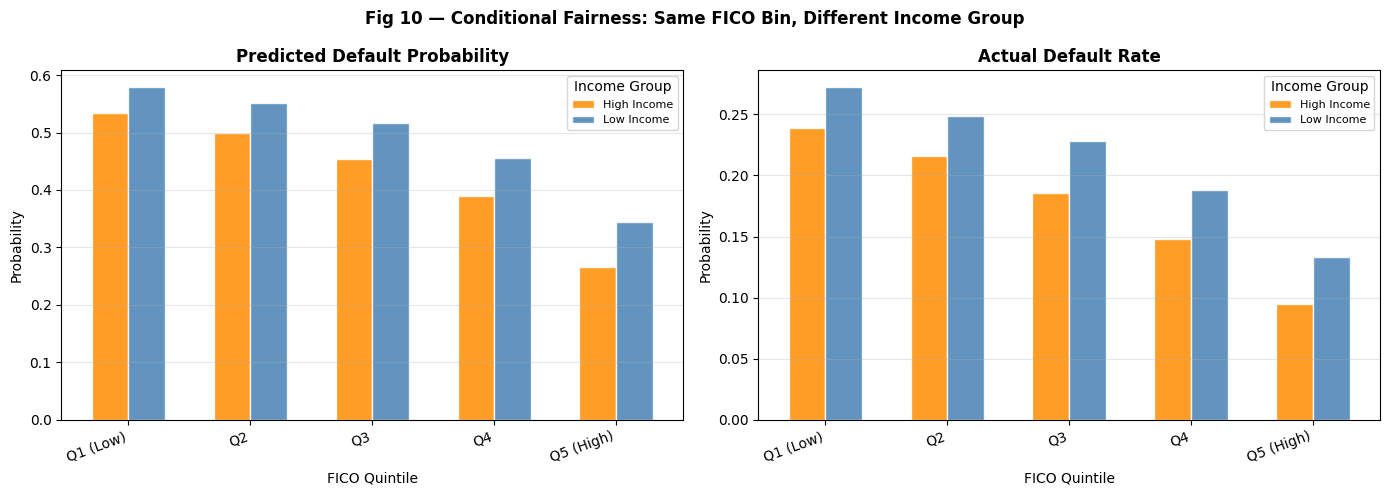

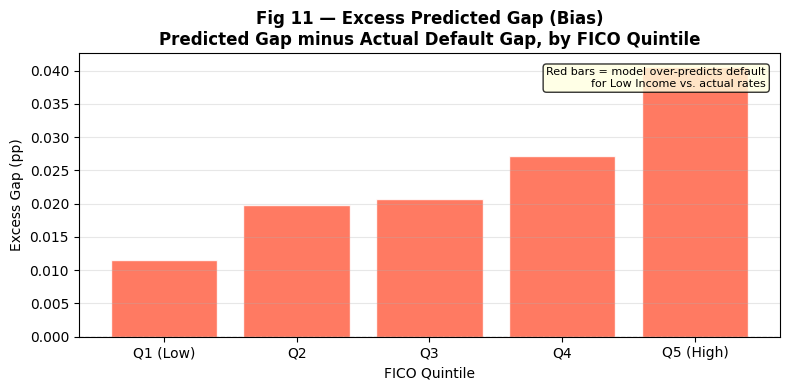


 FINAL SUMMARY: Fairness Gaps Across All Models — Table 2 (§5.2)

  Logistic Regression
    Model               : Logistic Regression
    AUC (Overall)       : 0.6846
    AUC (Low)           : 0.6701
    AUC (High)          : 0.6941
    DP Gap              : 0.1711
    EO Gap (TPR)        : 0.1462
    PP Gap (Prec.)      : 0.0132
    FPR Gap             : 0.1629

  Random Forest
    Model               : Random Forest
    AUC (Overall)       : 0.686
    AUC (Low)           : 0.6717
    AUC (High)          : 0.6954
    DP Gap              : 0.1593
    EO Gap (TPR)        : 0.1137
    PP Gap (Prec.)      : 0.019
    FPR Gap             : 0.1557

  XGBoost
    Model               : XGBoost
    AUC (Overall)       : 0.6898
    AUC (Low)           : 0.6751
    AUC (High)          : 0.6996
    DP Gap              : 0.1649
    EO Gap (TPR)        : 0.1238
    PP Gap (Prec.)      : 0.0156
    FPR Gap             : 0.1598

 All outputs saved to: /content/drive/MyDrive/Progetto_Fairness/
 Files

In [1]:
# ==============================================================================
# Do Algorithms Amplify Financial Inequality?
# Evidence from Causal Inference and Machine Learning in FinTech Lending
#
# Ronchetti Alessia — 260985
# MSc in Data Science, University of Trento
# Computational Social Science — A.A. 2025–2026
#
# PART 1   Fuzzy Regression Discontinuity Design (IV2SLS)
# PART 2   Algorithmic Fairness Audit (LR / RF / XGBoost)
# Dataset: LendingClub peer-to-peer loans, 2007–2018
# ==============================================================================


# ==============================================================================
# 0. DEPENDENCIES
# ==============================================================================
# Run once in Colab. Key packages:
# - linearmodels: IV2SLS with correct standard errors
# - shap, xgboost: feature attribution for the fairness audit
!pip install linearmodels shap xgboost -q


# ==============================================================================
# 1. IMPORTS
# ==============================================================================
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats as scipy_stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)   # fixed seed for reproducibility

# IV2SLS via linearmodels gives correct standard errors.
# Doing 2SLS by hand gives the right coefficients but wrong Stage-2 SEs.
try:
    from linearmodels.iv import IV2SLS
    USE_LINEARMODELS = True
    print("linearmodels found. Using IV2SLS for correct standard errors.")
except ImportError:
    USE_LINEARMODELS = False
    print("linearmodels not found. Install with: pip install linearmodels")
    print("Falling back to manual 2SLS (note: second-stage SEs are biased).")

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass


# ==============================================================================
# 2. PATH CONFIGURATION
# ==============================================================================
# PATH_CLEAN is built by Part 1 and reused by Part 2.
# Part 1 saves figures/tables in Progetto_RDD/; Part 2 in OUTPUT_DIR (Progetto_Fairness/).
PATH_ORIGINAL = "/content/drive/MyDrive/Progetto_RDD/accepted_2007_to_2018Q4.csv"
PATH_CLEAN    = "/content/drive/MyDrive/Progetto_RDD/lending_clean_small.csv"
OUTPUT_DIR    = "/content/drive/MyDrive/Progetto_Fairness/"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ==============================================================================
# 3. DATA LOADING AND PREPROCESSING
# Data Provenance and Preprocessing
# ==============================================================================
# Preprocessing :
#   - keep only resolved loans (Fully Paid, Charged Off, Default)
#   - default = 1 if Charged Off or Default, else 0
#   - keep 4 variables, drop rows with missing values
# The clean file is cached to avoid reloading the 1.5 GB original.
if os.path.exists(PATH_CLEAN):
    print("Clean file found.")
    df = pd.read_csv(PATH_CLEAN)
else:
    print("Clean file not found. Processing the original dataset...")
    cols = ['fico_range_low', 'int_rate', 'loan_status', 'annual_inc']
    df_raw = pd.read_csv(PATH_ORIGINAL, usecols=cols)

    if df_raw['int_rate'].dtype == 'object':
        df_raw['int_rate'] = df_raw['int_rate'].str.rstrip('%').astype(float)

    # keep only resolved loans, so the default outcome is observed
    completed_status = ['Fully Paid', 'Charged Off', 'Default']
    df = df_raw[df_raw['loan_status'].isin(completed_status)].copy()
    df['default'] = np.where(df['loan_status'].isin(['Charged Off', 'Default']), 1, 0)
    df = df.dropna()
    df.to_csv(PATH_CLEAN, index=False)
    print("Cleaning completed. Lightweight file saved.")


# ==============================================================================
# 4. SHARED FEATURE ENGINEERING
# Log-income transformation and median income split
# ==============================================================================
# log_annual_inc: log of income to reduce its right skew.
# income_group: split at the sample median into Low/High, two groups of
# roughly equal size. Both variables are used in Part 1 and Part 2.
df['log_annual_inc'] = np.log(df['annual_inc'].clip(lower=1))

median_income = df['annual_inc'].median()
df['income_group'] = np.where(
    df['annual_inc'] <= median_income, 'Low Income', 'High Income'
)

print(f"\nDataset shape         : {df.shape}")
print(f"Median annual income  : ${median_income:,.0f}")
print(f"Overall default rate  : {df['default'].mean():.3f}")
print(f"  Low Income          : {df[df['income_group']=='Low Income']['default'].mean():.3f}")
print(f"  High Income         : {df[df['income_group']=='High Income']['default'].mean():.3f}")


# ==============================================================================
# ==============================================================================
# PART 1 — CAUSAL INFERENCE: FUZZY REGRESSION DISCONTINUITY DESIGN
# RQ1: Does a lower interest rate at the FICO 740 threshold reduce the
# probability of default?
# ==============================================================================
# ==============================================================================


# ------------------------------------------------------------------------------
# 5. FIGURE 1 — Global interest-rate discontinuity across the full FICO range
# ------------------------------------------------------------------------------
# Motivates the FICO 740 instrument: interest rates jump down at 740,
# separating prime (>= 740) from near-prime (< 740) borrowers.
# The entry cutoff at 660 is shown for reference.
summary_global = df.groupby('fico_range_low')['int_rate'].mean().reset_index()

plt.figure(figsize=(8, 4.5))
plt.scatter(summary_global['fico_range_low'], summary_global['int_rate'],
            s=10, alpha=0.6, color='blue')
plt.axvline(x=660, color='red',   linestyle=':',  label='Entry Cutoff (660)')
plt.axvline(x=740, color='green', linestyle='--', linewidth=2,
            label='Agarwal Prime Cutoff (740)')
plt.title("Fig 1: Discontinuity in Interest Rate (Agarwal et al., 2018)")
plt.xlabel("FICO Score")
plt.ylabel("Average Interest Rate (%)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.savefig("/content/drive/MyDrive/Progetto_RDD/fig1_global_exploration.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 6. RDD SETUP
# Fuzzy RDD
# ------------------------------------------------------------------------------
# The FICO 740 threshold is used as an instrument for the interest rate.
# Two assumptions:
#   (i)  borrowers cannot precisely manipulate their FICO (Section 7, McCrary test)
#   (ii) no other variable jumps at 740 (Section 11, balance test)
# Baseline bandwidth: ±25 points [715, 765]; robustness in Section 14.

CUTOFF    = 740   # prime credit threshold
BANDWIDTH = 25    # baseline window [715, 765]; robustness in Section 14

subset = df[df['fico_range_low'].between(CUTOFF - BANDWIDTH, CUTOFF + BANDWIDTH)].copy()
subset['threshold']     = (subset['fico_range_low'] >= CUTOFF).astype(int)
subset['fico_centered'] = subset['fico_range_low'] - CUTOFF

print(f"\nSubset size within bandwidth [{CUTOFF-BANDWIDTH}, {CUTOFF+BANDWIDTH}]: "
      f"N = {len(subset):,}")


# ------------------------------------------------------------------------------
# 7. FIGURE 2 — McCrary density test at FICO 740
# ------------------------------------------------------------------------------
# McCrary density test for assumption (i): if borrowers cannot manipulate their
# FICO, the histogram should be smooth at 740.
# Result: smooth on both sides — no sign of manipulation.

plt.figure(figsize=(8, 4.5))
plt.hist(subset['fico_range_low'],
         bins=range(CUTOFF - BANDWIDTH, CUTOFF + BANDWIDTH + 1, 2),
         color='lightgray', edgecolor='black')
plt.axvline(x=CUTOFF, color='red', linestyle='dashed', linewidth=2,
            label=f'Cutoff ({CUTOFF})')
plt.title(f"Fig 2: Density Test (McCrary) at Cutoff {CUTOFF}")
plt.xlabel("FICO Score")
plt.ylabel("Frequency (Number of Borrowers)")
plt.legend()
plt.savefig(f"/content/drive/MyDrive/Progetto_RDD/fig2_density_test_{CUTOFF}.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 8. IV2SLS — Two-Stage Least Squares | tests H1a, H1b
# ------------------------------------------------------------------------------
# Stage 1:  int_rate = α₀ + α₁·Z + α₂·r̃ + ε
# Stage 2:  default  = β₀ + β₁·int̂_rate + β₂·r̃ + u
#   Z  = threshold indicator (1 if FICO >= 740), the instrument
#   r̃  = FICO centred at 740, the running variable
#   β₁ = LATE: causal effect of +1pp interest rate on P(default) near 740 (H1b)
#
# H1a: first-stage F > 10 means a strong instrument; F <= 10 is weak.
# H1b: LATE expected positive (debt-burden channel).
# Result : F = 3.31 (weak), LATE = 0.014 (p = 0.751) — not significant.

print("\n" + "=" * 60)
print(f" STAGE 1: Effect of Threshold ({CUTOFF}) on Interest Rate")
print("=" * 60)

# OLS first stage: F-statistic for H1a, HC3 robust SEs
first_stage = smf.ols("int_rate ~ threshold + fico_centered", data=subset).fit(
    cov_type='HC3')
print(first_stage.summary().tables[1])

# first-stage F on the instrument; rule of thumb F > 10 (H1a)
f_stat = (first_stage.params['threshold'] / first_stage.bse['threshold']) ** 2
print(f"\n  First-Stage F-statistic on instrument (threshold): {f_stat:.2f}")
if f_stat > 10:
    print("  H1a: SUPPORTED — strong instrument (F > 10).")
else:
    print("  H1a: NOT SUPPORTED — weak instrument (F <= 10).")

# IV2SLS (correct SEs via linearmodels) or manual OLS fallback
if USE_LINEARMODELS:
    print("\n" + "=" * 60)
    print(" STAGE 2 (LATE via IV2SLS): Effect of Interest Rate on Default")
    print("=" * 60)

    # IV2SLS(dependent, exog=controls, endog=int_rate, instruments=threshold)
    subset_iv = subset[['default', 'int_rate', 'fico_centered', 'threshold']].dropna().copy()
    subset_iv = sm.add_constant(subset_iv)

    iv_model = IV2SLS(
        dependent   = subset_iv['default'],
        exog        = subset_iv[['const', 'fico_centered']],
        endog       = subset_iv['int_rate'],
        instruments = subset_iv['threshold']
    ).fit(cov_type='robust')

    print(iv_model.summary.tables[1])
    print(f"\n  LATE (β₁): {iv_model.params['int_rate']:.4f}")
    print(f"  p-value:   {iv_model.pvalues['int_rate']:.4f}")

    late_coef = iv_model.params['int_rate']
    late_pval = iv_model.pvalues['int_rate']

else:
    # fallback: manual 2SLS — SEs are biased, use only as approximation
    print("\n" + "=" * 60)
    print(" STAGE 2 (LATE, manual — SEs are biased): Effect of Rate on Default")
    print(" Install linearmodels for correct inference: pip install linearmodels")
    print("=" * 60)

    subset['predicted_int_rate'] = first_stage.predict()
    second_stage = smf.ols("default ~ predicted_int_rate + fico_centered",
                           data=subset).fit(cov_type='HC3')
    print(second_stage.summary().tables[1])

    late_coef = second_stage.params['predicted_int_rate']
    late_pval = second_stage.pvalues['predicted_int_rate']

# LATE interpretation (H1b)
print(f"\n  LATE interpretation: a 1pp exogenous increase in interest rate")
print(f"  is associated with a {late_coef*100:.2f}pp change in P(default) for compliers near FICO 740.")


# ------------------------------------------------------------------------------
# 9. FIGURE 3 — First-stage discontinuity in interest rate at FICO 740
# ------------------------------------------------------------------------------
# Local OLS lines below/above the cutoff with binned scatter.
# Interest rates shift down at 740: ~10.4-10.5% just below, ~10.1% just above.
summary_local_rate = subset.groupby('fico_range_low')['int_rate'].mean().reset_index()

plt.figure(figsize=(8, 4.5))
sns.regplot(x='fico_range_low', y='int_rate',
            data=subset[subset['fico_range_low'] < CUTOFF],
            scatter=False, color='darkorange', label='Below Threshold')
sns.regplot(x='fico_range_low', y='int_rate',
            data=subset[subset['fico_range_low'] >= CUTOFF],
            scatter=False, color='green', label='Above Threshold')
plt.scatter(summary_local_rate['fico_range_low'], summary_local_rate['int_rate'],
            color='black', s=15, alpha=0.5)
plt.axvline(x=CUTOFF, color='red', linestyle='--',
            label=f'Cutoff ({CUTOFF})')
plt.title("Fig 3: First Stage — Discontinuity in Interest Rate at FICO 740 (Agarwal et al., 2018)")
plt.xlabel("FICO Score")
plt.ylabel("Average Interest Rate (%)")
plt.legend()
plt.savefig("/content/drive/MyDrive/Progetto_RDD/fig3_first_stage_plot.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 10. FIGURE 4 — Reduced-form relationship: FICO score vs default probability
# ------------------------------------------------------------------------------
# Default probability plotted directly against FICO, without instrumentation.
# It drops at 740, the same direction as H1b, even though the IV estimate is
# not significant.
summary_default = subset.groupby('fico_range_low')['default'].mean().reset_index()

plt.figure(figsize=(8, 4.5))
sns.regplot(x='fico_range_low', y='default',
            data=subset[subset['fico_range_low'] < CUTOFF],
            scatter=False, color='darkorange', label='Below Threshold')
sns.regplot(x='fico_range_low', y='default',
            data=subset[subset['fico_range_low'] >= CUTOFF],
            scatter=False, color='green', label='Above Threshold')
plt.scatter(summary_default['fico_range_low'], summary_default['default'],
            color='black', s=15, alpha=0.5)
plt.axvline(x=CUTOFF, color='red', linestyle='--',
            label=f'Cutoff ({CUTOFF})')
plt.title(f"Fig 4: Reduced Form — Default Probability at Cutoff {CUTOFF}")
plt.xlabel("FICO Score")
plt.ylabel("Average Default Probability")
plt.legend()
plt.savefig("/content/drive/MyDrive/Progetto_RDD/fig4_outcome_plot.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 11. FIGURE 12 — Covariate balance: log(income) at FICO 740
# Note: titled "Fig 5" here (5th figure of Part 1), but it is Figure 12 in the paper.
# ------------------------------------------------------------------------------
# Tests assumption (ii): no covariate should jump at 740. A significant income
# jump would break local comparability and bias the LATE upward.
# Result : t = -2.452, p = 0.014 — significant income jump found.
summary_income = subset.groupby('fico_range_low')['log_annual_inc'].mean().reset_index()

plt.figure(figsize=(8, 4.5))
sns.regplot(x='fico_range_low', y='log_annual_inc',
            data=subset[subset['fico_range_low'] < CUTOFF],
            scatter=False, color='darkorange', label='Below Threshold')
sns.regplot(x='fico_range_low', y='log_annual_inc',
            data=subset[subset['fico_range_low'] >= CUTOFF],
            scatter=False, color='green', label='Above Threshold')
plt.scatter(summary_income['fico_range_low'], summary_income['log_annual_inc'],
            color='black', s=15, alpha=0.5)
plt.axvline(x=CUTOFF, color='red', linestyle='--',
            label=f'Cutoff ({CUTOFF})')
plt.title("Fig 5: Covariate Balance — Log(Income) at Cutoff (Fuster et al., 2022)")
plt.xlabel("FICO Score")
plt.ylabel("Log(Average Annual Income)")
plt.legend()
plt.savefig("/content/drive/MyDrive/Progetto_RDD/fig5_balance_check.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

# balance t-test on log(income)
t_stat, p_balance = scipy_stats.ttest_ind(
    subset.loc[subset['threshold'] == 0, 'log_annual_inc'],
    subset.loc[subset['threshold'] == 1, 'log_annual_inc']
)
print(f"\n  Balance t-test on log(income): t = {t_stat:.3f}, p = {p_balance:.4f}")
if p_balance > 0.05:
    print("  Local comparability supported — no significant income jump at cutoff.")
else:
    print("  Significant income discontinuity detected.")

print("\n Balance check complete.")


# ------------------------------------------------------------------------------
# 12. HETEROGENEITY ANALYSIS — income subgroups (H1c)
# ------------------------------------------------------------------------------
# H1c: the LATE should be larger for low-income borrowers (more financially
# fragile). With small subgroups, we look at sign/direction, not significance.
# Result : LATE = +0.066 (Low, p = 0.151), -0.285 (High, p = 0.723);
# neither significant, so H1c cannot be confirmed or rejected.

print("\n" + "=" * 60)
print(" HETEROGENEITY ANALYSIS: Distributional Impacts (Fuster et al., 2022)")
print("=" * 60)

subset_low_inc  = subset[subset['annual_inc'] <= median_income].copy()
subset_high_inc = subset[subset['annual_inc'] >  median_income].copy()

def run_2sls_group(data, label):
    """
    Run IV2SLS (or manual OLS fallback) on a subgroup.
    Used for H1c heterogeneity and bandwidth robustness.
    Returns the LATE coefficient and its p-value.
    """
    if USE_LINEARMODELS:
        data_iv = data[['default', 'int_rate', 'fico_centered', 'threshold']].dropna().copy()
        data_iv = sm.add_constant(data_iv)
        model = IV2SLS(
            dependent   = data_iv['default'],
            exog        = data_iv[['const', 'fico_centered']],
            endog       = data_iv['int_rate'],
            instruments = data_iv['threshold']
        ).fit(cov_type='robust')
        coef = model.params['int_rate']
        pval = model.pvalues['int_rate']
    else:
        fs   = smf.ols("int_rate ~ threshold + fico_centered", data=data).fit(cov_type='HC3')
        data = data.copy()
        data['predicted_int_rate'] = fs.predict()
        ss   = smf.ols("default ~ predicted_int_rate + fico_centered", data=data).fit(cov_type='HC3')
        coef = ss.params['predicted_int_rate']
        pval = ss.pvalues['predicted_int_rate']
    return coef, pval

late_low,  pval_low  = run_2sls_group(subset_low_inc,  "LOW Income")
late_high, pval_high = run_2sls_group(subset_high_inc, "HIGH Income")

print(f"  Median Income Threshold: ${median_income:,.0f}")
print(f"  -> LATE (Rate → Default) for LOW Income:  {late_low:.4f}  "
      f"(p = {pval_low:.4f}{'*' if pval_low < 0.1 else ''})")
print(f"  -> LATE (Rate → Default) for HIGH Income: {late_high:.4f}  "
      f"(p = {pval_high:.4f}{'*' if pval_high < 0.1 else ''})")

if abs(late_low) > abs(late_high):
    print("\n  H1c: Direction consistent with hypothesis — larger LATE for low-income borrowers.")
else:
    print("\n  H1c: Low-income borrowers do not show larger sensitivity in this bandwidth.")
print("  Non-significance in subgroups is expected given reduced N.")


# ------------------------------------------------------------------------------
# 13. TABLE 1 — Descriptive statistics at the FICO 740 cutoff
# ------------------------------------------------------------------------------
# Mean/SD/min/max of interest rate, income, and default below vs above FICO 740
# (within ±25 points). Key figures : interest rate 11.20% vs 9.68%
# (~1.5pp gap); default 14% vs 11%; income similar (~$82k vs ~$83k).
print("\n" + "=" * 60)
print(" TABLE 1 — Descriptive Statistics at FICO 740 Cutoff")
print("=" * 60)

vars_to_describe = ['int_rate', 'annual_inc', 'default']
summary_stats = subset.groupby('threshold')[vars_to_describe].agg(['mean', 'std', 'min', 'max'])
summary_stats = summary_stats.T.round(2)
summary_stats.columns = [f'Below Threshold (FICO < {CUTOFF})',
                          f'Above Threshold (FICO ≥ {CUTOFF})']
print(summary_stats)
summary_stats.to_csv("/content/drive/MyDrive/Progetto_RDD/table1_summary_stats.csv")


# ------------------------------------------------------------------------------
# 14. BANDWIDTH ROBUSTNESS — sensitivity of LATE to bandwidth choice
# ------------------------------------------------------------------------------
# A robust LATE should keep its sign and size across bandwidths.
# Result : LATE = -0.031 (±15), +0.014 (±25), +0.022 (±35).
# The sign flips between ±15 and ±25; the only significant value (±35,
# p = 0.036) is also the most likely to break local comparability.

print("\n" + "=" * 60)
print(" ROBUSTNESS CHECKS: Bandwidth Variation")
print("=" * 60)

bandwidths_to_test = [15, 25, 35]   # narrow / baseline / wide

for bw in bandwidths_to_test:
    temp = df[df['fico_range_low'].between(CUTOFF - bw, CUTOFF + bw)].copy()
    temp['threshold']     = (temp['fico_range_low'] >= CUTOFF).astype(int)
    temp['fico_centered'] = temp['fico_range_low'] - CUTOFF

    coef, pval = run_2sls_group(temp, f"BW={bw}")

    sig_label = ("*** p<0.01" if pval < 0.01 else
                 "**  p<0.05" if pval < 0.05 else
                 "*   p<0.10" if pval < 0.10 else
                 "    n.s.")
    print(f"  BW = {bw:2d}  FICO [{CUTOFF-bw:3d}, {CUTOFF+bw:3d}]  "
          f"LATE = {coef:+.4f}   p = {pval:.4f}  {sig_label}")

print("\n  Sign flip between ±15 and ±25.")


# ------------------------------------------------------------------------------
# 15. PLACEBO TESTS — falsification at fake cutoffs
# ------------------------------------------------------------------------------
# A good instrument should make rates jump only at 740.
# Pass = p > 0.05 (no significant jump at a fake cutoff).
# Result : 700, 780, 800 pass; 720 and 760 are marginal (rate grid);
# 660 has a large +7.73pp jump, showing other structural cutoffs exist.

print("\n" + "=" * 60)
print(" PLACEBO TESTS — Fake Cutoffs ")
print(" Pass criterion: p > 0.05 — no significant rate jump at fake cutoff.")
print("=" * 60)

fake_cutoffs = [660, 700, 720, 760, 780, 800]

for f_cut in fake_cutoffs:
    temp = df[df['fico_range_low'].between(f_cut - BANDWIDTH, f_cut + BANDWIDTH)].copy()
    if len(temp) < 100:
        print(f"  Cutoff = {f_cut}: insufficient data (N={len(temp)}), skipped.")
        continue

    temp['fake_threshold'] = (temp['fico_range_low'] >= f_cut).astype(int)
    temp['fico_centered']  = temp['fico_range_low'] - f_cut

    placebo_fs = smf.ols("int_rate ~ fake_threshold + fico_centered",
                         data=temp).fit(cov_type='HC3')

    coef_p = placebo_fs.params['fake_threshold']
    pval_p = placebo_fs.pvalues['fake_threshold']

    result = "PASS" if pval_p > 0.05 else "FAIL (significant jump at fake cutoff)"

    print(f"  Fake cutoff = {f_cut:3d}  |  Rate jump = {coef_p:+.4f}  |  "
          f"p = {pval_p:.4f}  |  {result}")

print("\n  Cutoff 660 FAIL expected — documents structural discontinuities.")
print("  Cutoffs 720, 760: marginal significance expected from rate grid.")


# ==============================================================================
# ==============================================================================
# PART 2 — ALGORITHMIC FAIRNESS AUDIT
# RQ2: Do ML credit models produce biased predictions against low-income
# borrowers, even when credit quality is held fixed?
# ==============================================================================
# ==============================================================================


# ------------------------------------------------------------------------------
# 16. MODELING DATASET SETUP
# ------------------------------------------------------------------------------
# Three features for all models: fico_range_low, int_rate, log_annual_inc.
# This small feature set isolates the variables that matter most for the
# research questions. income_group was built in Section 4.

FEATURES = ['fico_range_low', 'int_rate', 'log_annual_inc']
TARGET   = 'default'

model_df = (df[FEATURES + [TARGET, 'income_group']]
            .dropna()
            .copy()
            .reset_index(drop=True))

print(f"\nModeling dataset  : N = {len(model_df):,}")


# ------------------------------------------------------------------------------
# 17. TRAIN / TEST SPLIT
# ------------------------------------------------------------------------------
# All fairness metrics use the test set only. Stratifying keeps the ~14%
# default rate in both splits.
X      = model_df[FEATURES]
y      = model_df[TARGET]
groups = model_df['income_group']

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain N = {len(X_train):,}  |  Test N = {len(X_test):,}")


# ------------------------------------------------------------------------------
# 18. TRAIN THREE CLASSIFIERS
# ------------------------------------------------------------------------------
# Three models of increasing complexity:
#   LR  = Logistic Regression (L2), the simple baseline
#   RF  = Random Forest, 200 trees, depth 6
#   XGB = XGBoost, 200 trees, depth 4, lr 0.05
# Class imbalance (~14% default) handled with balanced weights (LR, RF) and
# scale_pos_weight (XGB). Only LR needs scaled features.
# XGBoost is the main model for SHAP and conditional fairness:
# highest AUC = 0.690.

# scale features for Logistic Regression only
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 18.1 Logistic Regression — baseline
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr.predict(X_test_sc)

# 18.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=6,
    random_state=42, class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)

# 18.3 XGBoost — main model for SHAP and conditional fairness
spw = (y_train == 0).sum() / (y_train == 1).sum()   # scale_pos_weight for class imbalance
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    scale_pos_weight=spw, random_state=42,
    eval_metric='auc', verbosity=0
)
xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred  = xgb_model.predict(X_test)

# AUC feeds Table 2; full table assembled in Section 24.
# Result: AUC 0.690 (XGB), 0.686 (RF), 0.685 (LR) — <0.5pp gain
# from more complex models on this small feature set.
print("\n" + "=" * 60)
print(" MODEL PERFORMANCE (Test Set) — Table 2 ")
print("=" * 60)
for name, proba, pred in [
    ("Logistic Regression", lr_proba,  lr_pred),
    ("Random Forest",       rf_proba,  rf_pred),
    ("XGBoost",             xgb_proba, xgb_pred)
]:
    auc = roc_auc_score(y_test, proba)
    print(f"\n{name}  —  ROC-AUC: {auc:.4f}")
    print(classification_report(
        y_test, pred,
        target_names=['No Default', 'Default'],
        digits=3
    ))


# ------------------------------------------------------------------------------
# 19. FAIRNESS METRIC COMPUTATION
# ------------------------------------------------------------------------------
# Three group-fairness gaps, each as |Low - High| :
#   DP (Demographic Parity): gap in positive-prediction rate
#   EO (Equal Opportunity):  gap in true positive rate (recall)
#   PP (Predictive Parity):  gap in precision among flagged borrowers
# The three cannot all hold at once when base rates differ.
# Result against H2a: LR has the LARGEST DP (0.171) and EO (0.146) gaps,
# so the bias is structural in the data, not caused by model complexity.

def compute_fairness_metrics(y_true, y_proba, groups, threshold=0.5):
    """
    Compute DP, EO, PP, FPR and AUC per income group, plus the |Low - High|
    gaps. threshold: decision threshold (default 0.5).
    """
    y_pred = (y_proba >= threshold).astype(int)
    results = {}

    for group in ['Low Income', 'High Income']:
        mask = groups == group
        yt   = np.array(y_true)[mask]
        yp   = y_pred[mask]
        yprb = y_proba[mask]

        tp = ((yp == 1) & (yt == 1)).sum()
        fp = ((yp == 1) & (yt == 0)).sum()
        fn = ((yp == 0) & (yt == 1)).sum()
        tn = ((yp == 0) & (yt == 0)).sum()

        results[group] = {
            'N':              int(mask.sum()),
            'Pos. Rate (DP)': float(yp.mean()),
            'TPR (EO)':       float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan,
            'Precision (PP)': float(tp / (tp + fp)) if (tp + fp) > 0 else np.nan,
            'FPR':            float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
            'AUC':            float(roc_auc_score(yt, yprb)),
        }

    gaps = {
        metric: abs(results['Low Income'][metric] - results['High Income'][metric])
        for metric in ['Pos. Rate (DP)', 'TPR (EO)', 'Precision (PP)', 'FPR', 'AUC']
    }
    return results, gaps


# Tables 2 and 3
print("\n" + "=" * 60)
print(" FAIRNESS METRICS BY INCOME GROUP — Tables 2 & 3 ")
print("=" * 60)

fairness_rows = []
for name, proba, pred in [
    ("Logistic Regression", lr_proba,  lr_pred),
    ("Random Forest",       rf_proba,  rf_pred),
    ("XGBoost",             xgb_proba, xgb_pred)
]:
    m, g = compute_fairness_metrics(y_test.values, proba, g_test.values)
    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    row = {'Model': name}
    for group in ['Low Income', 'High Income']:
        print(f"  {group}  (N={m[group]['N']:,})")
        for k, v in m[group].items():
            if k != 'N':
                print(f"    {k:<18}: {v:.4f}")
                row[f"{group}|{k}"] = round(v, 4)
    print("  Gaps (|Low − High|):")
    for k, v in g.items():
        print(f"    {k:<18}: {v:.4f}")
        row[f"Gap|{k}"] = round(v, 4)
    fairness_rows.append(row)

fairness_df = pd.DataFrame(fairness_rows)
fairness_df.to_csv(OUTPUT_DIR + "table3_fairness_metrics.csv", index=False)


# ------------------------------------------------------------------------------
# 20. FIGURE 5 — ROC Curves by Income Group
# ------------------------------------------------------------------------------
# ROC and AUC by income group for the three models. High Income AUC is always
# higher (gap 0.024-0.025, Table 2): the features carry less signal for
# low-income borrowers, in every model.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, proba) in zip(axes, [
    ("Logistic Regression", lr_proba),
    ("Random Forest",       rf_proba),
    ("XGBoost",             xgb_proba)
]):
    for group, color, ls in [
        ("Low Income",  "darkorange", "-"),
        ("High Income", "steelblue",  "--")
    ]:
        mask = g_test.values == group
        fpr, tpr, _ = roc_curve(y_test.values[mask], proba[mask])
        auc = roc_auc_score(y_test.values[mask], proba[mask])
        ax.plot(fpr, tpr, color=color, linestyle=ls,
                label=f"{group}  (AUC={auc:.3f})")

    ax.plot([0, 1], [0, 1], 'k:', alpha=0.4)
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Fig 5 — ROC Curves by Income Group", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig1_roc_by_group.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 21. FIGURE 6 — Fairness metric comparison across models
# ------------------------------------------------------------------------------
# Bar chart of DP, EO and PP by income group for the three models.
# LR shows the largest DP and EO gaps, against H2a: the bias is structural.
metrics_to_plot  = ['Pos. Rate (DP)', 'TPR (EO)', 'Precision (PP)']
metric_labels    = ['Demographic Parity\n(Positive Rate)',
                    'Equal Opportunity\n(TPR)',
                    'Predictive Parity\n(Precision)']
model_names      = ["LR", "RF", "XGB"]
model_proba_list = [lr_proba, rf_proba, xgb_proba]
model_pred_list  = [lr_pred,  rf_pred,  xgb_pred]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, label in zip(axes, metrics_to_plot, metric_labels):
    low_vals, high_vals = [], []
    for proba in model_proba_list:
        m, _ = compute_fairness_metrics(y_test.values, proba, g_test.values)
        low_vals.append(m['Low Income'][metric])
        high_vals.append(m['High Income'][metric])

    x     = np.arange(len(model_names))
    width = 0.35
    ax.bar(x - width/2, low_vals,  width,
           label='Low Income',  color='darkorange', alpha=0.85, edgecolor='white')
    ax.bar(x + width/2, high_vals, width,
           label='High Income', color='steelblue',  alpha=0.85, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, fontweight='bold')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel("Rate")
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle("Fig 6 — Fairness Metrics by Model and Income Group", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig2_fairness_bars.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 22. SHAP ANALYSIS — XGBoost feature attribution | Figures 7, 8, 9 | Table 4
# ------------------------------------------------------------------------------
# Computed on 50,000 test observations. Three outputs:
#   Fig 7 (bar): int_rate dominates (~0.58), ~6x more than income (~0.10)
#     or FICO (~0.08).
#   Fig 8 (beeswarm): income pushes low-income predictions up and high-income
#     ones down — the signature of proxy discrimination.
#   Fig 9 / Table 4: mean |SHAP| by group. H2b not confirmed literally
#     (High Income has higher |SHAP|), but income works in opposite directions
#     for the two groups.

print("\n" + "=" * 60)
print(" SHAP ANALYSIS — XGBoost Feature Importance by Income Group")
print("=" * 60)

sample_size = min(50_000, len(X_test))
sample_idx  = np.random.choice(len(X_test), sample_size, replace=False)

X_test_samp = X_test.iloc[sample_idx].reset_index(drop=True)
g_test_samp = g_test.iloc[sample_idx].reset_index(drop=True)
y_test_samp = y_test.iloc[sample_idx].reset_index(drop=True)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_samp)   # shape: (N, n_features)

# global mean |SHAP| bar — Figure 7
plt.figure(figsize=(7, 4))
shap.summary_plot(
    shap_values, X_test_samp,
    feature_names=FEATURES,
    plot_type='bar',
    show=False
)
plt.title("Fig 7 — Mean |SHAP|: Global Feature Importance (XGBoost)",
          fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig3_shap_global.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

# beeswarm: directional contributions — Figure 8
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values, X_test_samp,
    feature_names=FEATURES,
    show=False
)
plt.title("Fig 8 — SHAP Beeswarm (XGBoost)", fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig4_shap_beeswarm.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

# mean |SHAP| by income group — Figure 9 / Table 4 (H2b)
low_mask  = (g_test_samp.values == 'Low Income')
high_mask = (g_test_samp.values == 'High Income')

mean_shap_low  = np.abs(shap_values[low_mask]).mean(axis=0)
mean_shap_high = np.abs(shap_values[high_mask]).mean(axis=0)

shap_df = pd.DataFrame({
    'Feature':    FEATURES,
    'Low Income':  mean_shap_low,
    'High Income': mean_shap_high
})
print("\n  Mean |SHAP| by income group (Table 4):")
print(shap_df.to_string(index=False))
shap_df.to_csv(OUTPUT_DIR + "table4_shap_by_group.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
x     = np.arange(len(FEATURES))
width = 0.35
ax.bar(x - width/2, mean_shap_low,  width,
       label='Low Income',  color='darkorange', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, mean_shap_high, width,
       label='High Income', color='steelblue',  alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=10)
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("Fig 9 — Mean |SHAP| by Feature and Income Group (XGBoost)",
             fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig5_shap_by_group.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 23. CONDITIONAL FAIRNESS within-FICO quintile analysis | Figures 10, 11 | Tables 5, 6
# ------------------------------------------------------------------------------
# H2c (the strictest test): inside each FICO quintile, XGBoost predicts
# higher default for low-income borrowers, and by more than the real gap.
# Excess bias :
#   ExcessBias_q = (pred_Low - pred_High) - (actual_Low - actual_High)
# Positive = the model over-penalises low-income borrowers beyond their real
# default behaviour — the signature of proxy discrimination.
# Result (H2c confirmed): excess bias is positive in all 5 quintiles and
# grows from 1.16pp (Q1) to 4.06pp (Q5), i.e. largest where FICO is highest.

print("\n" + "=" * 60)
print(" CONDITIONAL FAIRNESS — Within-FICO Quintile Analysis (H2c)")
print("=" * 60)

test_df = X_test.copy().reset_index(drop=True)
test_df['y_true']       = y_test.values
test_df['xgb_proba']    = xgb_proba
test_df['income_group'] = g_test.values

# FICO quintiles: Q1 = lowest scores, Q5 = highest
test_df['fico_bin'] = pd.qcut(
    test_df['fico_range_low'], q=5,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']
)

cond = (test_df
        .groupby(['fico_bin', 'income_group'], observed=True)
        .agg(
            N              = ('xgb_proba', 'count'),
            pred_prob_mean = ('xgb_proba', 'mean'),
            actual_default = ('y_true',    'mean')
        )
        .reset_index())

print(cond.to_string(index=False))
cond.to_csv(OUTPUT_DIR + "table5_conditional_fairness.csv", index=False)

# excess bias = predicted gap - actual gap, per quintile (H2c)
pivot_pred = cond.pivot(index='fico_bin', columns='income_group',
                         values='pred_prob_mean')
pivot_true = cond.pivot(index='fico_bin', columns='income_group',
                         values='actual_default')

pred_gap = pivot_pred['Low Income'] - pivot_pred['High Income']
true_gap = pivot_true['Low Income'] - pivot_true['High Income']
bias_gap = pred_gap - true_gap   # excess predicted gap

print("\n  Within-FICO gaps (Low minus High) — Table 6 :")
gap_df = pd.DataFrame({
    'Predicted gap': pred_gap.round(4),
    'Actual gap':    true_gap.round(4),
    'Excess bias':   bias_gap.round(4)
})
print(gap_df.to_string())
gap_df.to_csv(OUTPUT_DIR + "table6_bias_gaps.csv")

# Figure 10 — predicted vs actual within FICO bins
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pivot, title in [
    (axes[0], pivot_pred, "Predicted Default Probability"),
    (axes[1], pivot_true, "Actual Default Rate")
]:
    pivot.plot(kind='bar', ax=ax,
               color=['darkorange', 'steelblue'],
               alpha=0.85, edgecolor='white', width=0.6)
    ax.set_xticklabels(pivot.index, rotation=20, ha='right')
    ax.set_xlabel("FICO Quintile")
    ax.set_ylabel("Probability")
    ax.set_title(title, fontweight='bold')
    ax.legend(title='Income Group', fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(
    "Fig 10 — Conditional Fairness: Same FICO Bin, Different Income Group",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig6_conditional_fairness.pdf",
            format='pdf', bbox_inches='tight')
plt.show()

# Figure 11 — excess bias per FICO quintile (H2c)
# All bars positive and rising: H2c confirmed. As FICO loses power at the top,
# the model leans more on income than the data justify.
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in bias_gap]
ax.bar(bias_gap.index, bias_gap.values, color=colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel("FICO Quintile")
ax.set_ylabel("Excess Gap (pp)")
ax.set_title(
    "Fig 11 — Excess Predicted Gap (Bias)\n"
    "Predicted Gap minus Actual Default Gap, by FICO Quintile",
    fontweight='bold'
)
ax.grid(True, axis='y', alpha=0.3)
ax.annotate(
    "Red bars = model over-predicts default\nfor Low Income vs. actual rates",
    xy=(0.98, 0.95), xycoords='axes fraction',
    ha='right', va='top', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8)
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "fig7_excess_bias.pdf",
            format='pdf', bbox_inches='tight')
plt.show()


# ------------------------------------------------------------------------------
# 24. TABLE 2 — Summary of fairness gaps across all models
# ------------------------------------------------------------------------------
# Collects AUC (overall/Low/High) and DP/EO/PP/FPR gaps for all three models.
# Better AUC does not mean better fairness: XGB beats LR by <0.5pp AUC while
# the gaps stay essentially the same.

print("\n" + "=" * 60)
print(" FINAL SUMMARY: Fairness Gaps Across All Models — Table 2 ")
print("=" * 60)

summary_rows = []
for name, proba, pred in [
    ("Logistic Regression", lr_proba,  lr_pred),
    ("Random Forest",       rf_proba,  rf_pred),
    ("XGBoost",             xgb_proba, xgb_pred)
]:
    m, g = compute_fairness_metrics(y_test.values, proba, g_test.values)
    row  = {
        'Model':          name,
        'AUC (Overall)':  round(roc_auc_score(y_test, proba), 4),
        'AUC (Low)':      round(m['Low Income']['AUC'],        4),
        'AUC (High)':     round(m['High Income']['AUC'],       4),
        'DP Gap':         round(g['Pos. Rate (DP)'],           4),
        'EO Gap (TPR)':   round(g['TPR (EO)'],                 4),
        'PP Gap (Prec.)': round(g['Precision (PP)'],           4),
        'FPR Gap':        round(g['FPR'],                      4),
    }
    summary_rows.append(row)
    print(f"\n  {name}")
    for k, v in row.items():
        print(f"    {k:<20}: {v}")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR + "table_summary_fairness.csv", index=False)

print(f"\n All outputs saved to: {OUTPUT_DIR}")
print(" Files produced:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"   {f}")